# ta-dbscan Stop Detection

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# Imports
import nomad.io.base as loader
import geopandas as gpd
from shapely.geometry import box
from nomad.stop_detection.viz import plot_stops_barcode, plot_time_barcode, plot_stops, plot_pings, _plot_base_geometry, plot_circles
import nomad.stop_detection.dbscan as DBSCAN

import nomad.data as data_folder
from pathlib import Path

from nomad.city_gen import City
import pandas as pd
import datetime
import json
import matplotlib.dates as mdates
import pandas as pd
import nomad.generation.viz as viz
from nomad.traj_gen import Agent, condense_destinations
import nomad.stop_detection.utils as utils

In [2]:
# Parameters according to the config file
data_dir = Path(data_folder.__file__).parent
city = City.from_geopackage(data_dir / 'garden-city.gpkg')
buildings = gpd.read_parquet(data_dir / 'garden-city-buildings-mercator.parquet')

# Destination Diary for 2 stop trajectory

In [3]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=2, freq='90min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [90]*2  # in minutes

location = ['w-x17-y10'] + ['r-x19-y11']


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)
destinations

,datetime,timestamp,duration,location
0,2024-06-01 00:00:00-08:00,1717228800,90,w-x17-y10
1,2024-06-01 01:30:00-08:00,1717234200,90,r-x19-y11


In [18]:
seed = 25
dist_thresh = 15/15
time_thresh=120
dur_min=5
min_pts = 3
ha=16/15

Charlie = Agent(identifier="Andres",
                city=city)

Charlie.generate_trajectory(destination_diary=destinations,
                            seed=seed,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=6,
                          seed=seed,
                          ha=ha)

traj = Charlie.sparse_traj

pre_labels = DBSCAN.ta_dbscan_labels(traj,
                                time_thresh=time_thresh,
                                dist_thresh=dist_thresh,
                                min_pts=min_pts,
                                remove_overlaps=False,
                                return_cores=True,
                                timestamp='timestamp')
pre_labels.name = "cluster_overlaps"

labels = DBSCAN.ta_dbscan_labels(traj,
                                time_thresh=time_thresh,
                                dist_thresh=dist_thresh,
                                min_pts=min_pts,
                                remove_overlaps=False,
                                return_cores=False,
                                timestamp='timestamp')
labels.name = "cluster"


In [19]:
merged = traj.join(labels)

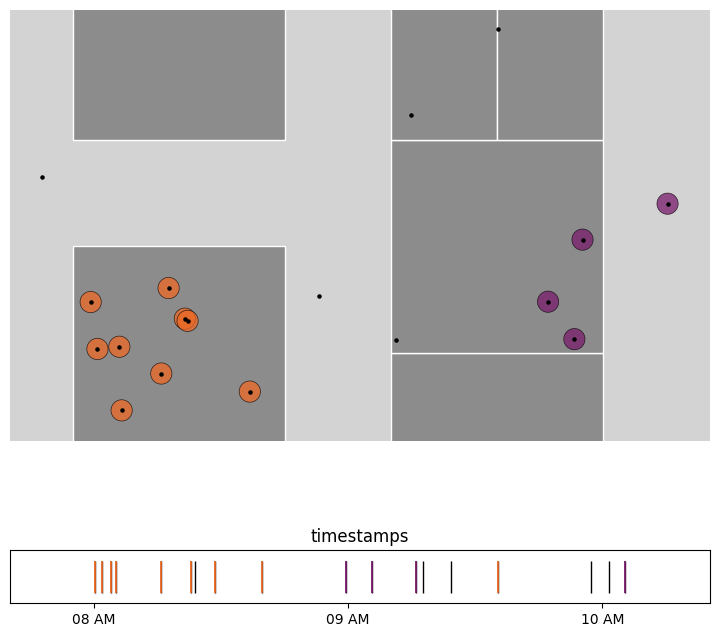

In [20]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(7,8),
                                         gridspec_kw={'height_ratios':[15,1]})

# Plot colored pings
plot_circles(merged, ax=ax_map, radius=0.1, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(merged, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(merged['timestamp'], ax=ax_barcode, set_xlim=True)
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(merged, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1.3)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=0)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()

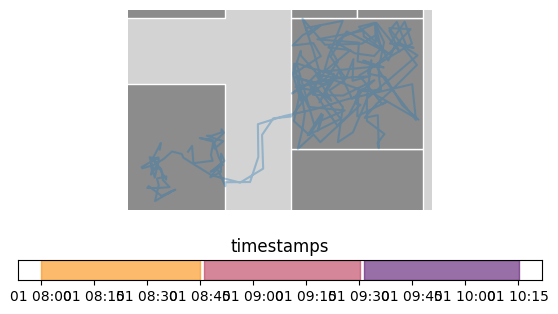

In [68]:
## Ground truth only
traj = Charlie.trajectory
stops = Charlie.diary.dropna()

fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(6,3.5),gridspec_kw={"height_ratios":[10,1]})



# Plot colored pings
plot_pings(traj, ax=ax_map, radius=0.13, alpha=0, base_geometry=city.buildings_gdf, base_geom_color="#8C8C8C", base_geom_background="#D3D3D3")
ax_map.plot(traj.x, traj.y, alpha=0.35)
#ax_map.set_axis_off()
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap=‘inferno_r’, set_xlim=False, timestamp=‘timestamp’)
plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.6, cmap="inferno_r", set_xlim=False, timestamp="timestamp")

ax_barcode.set_title("timestamps")
plt.tight_layout(pad=2)
plt.savefig("true_clusters.svg" , format="svg")
plt.savefig("true_clusters.png" , format="png", dpi=300)
plt.show()

# Destination Diary for 3 stop trajectory with many-visits-to-one-poi problem

In [7]:
start = '2024-06-01 00:00-08:00'

start_time = pd.date_range(start=start, periods=3, freq='45min')
unix_timestamp = [int(t.timestamp()) for t in start_time]
duration = [45]*3  # in minutes

location = ['w-x17-y10'] + ['r-x19-y11'] +  ['w-x17-y10']


destinations = pd.DataFrame(
    {
        "datetime":start_time,
         "timestamp":unix_timestamp,
         "duration":duration,
         "location":location
    }
)

destinations = condense_destinations(destinations)
destinations

,datetime,timestamp,duration,location
0,2024-06-01 00:00:00-08:00,1717228800,45,w-x17-y10
1,2024-06-01 00:45:00-08:00,1717231500,45,r-x19-y11
2,2024-06-01 01:30:00-08:00,1717234200,45,w-x17-y10


In [49]:
seed = 30 #33
dist_thresh = 10/15
time_thresh=120
dur_min=5
min_pts = 3
ha=13/15

Charlie = Agent(identifier="Andres",
                city=city)

Charlie.generate_trajectory(destination_diary=destinations,
                            seed=seed,
                            dt=0.15)

Charlie.sample_trajectory(beta_start=None,
                          beta_durations=None,
                          beta_ping=7,
                          seed=seed,
                          ha=ha)

In [50]:
traj = Charlie.sparse_traj
labels = DBSCAN.ta_dbscan_labels(traj,
                                time_thresh=time_thresh,
                                dist_thresh=dist_thresh,
                                min_pts=min_pts,
                                remove_overlaps=False,
                                return_cores=False,
                                timestamp='timestamp')

merged = traj.join(labels)

In [51]:
traj = merged
#traj['cluster'] = traj['cluster_adjusted']

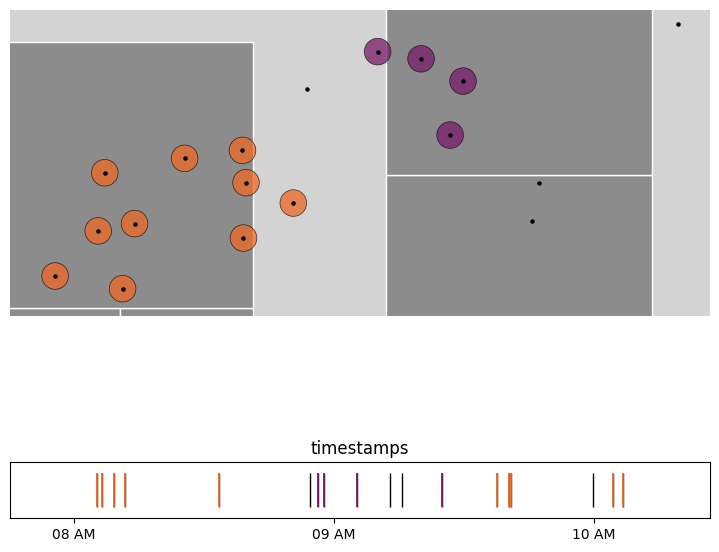

In [52]:
fig, (ax_map, ax_barcode) = plt.subplots(2, 1, figsize=(7,8),
                                         gridspec_kw={'height_ratios':[15,1]})

# Plot colored pings
plot_circles(traj, ax=ax_map, radius=0.1, color='cluster', cmap='inferno_r', base_geometry=city.buildings_gdf, base_geom_color='#8c8c8c', base_geom_background='#d3d3d3')
plot_pings(traj, ax=ax_map, s=5, color='black')
#ax_map.set_axis_off()
plot_time_barcode(traj['timestamp'], ax=ax_barcode, set_xlim=True)
#plot_stops_barcode(stops, ax=ax_barcode, stop_alpha=0.5, cmap='inferno_r', set_xlim=False, timestamp='timestamp')
#plot_stops_barcode(stops, ax=ax_barcode, stop_color='#d3d3d3', cmap='inferno_r', set_xlim=False, timestamp='timestamp')
plot_time_barcode(traj, color='cluster', ax=ax_barcode, cmap='inferno_r', set_xlim=False, lw=1.3)
ax_barcode.set_title("timestamps")
plt.tight_layout(pad=0)
plt.savefig('normal_clusters.svg' , format='svg')
plt.savefig('normal_clusters.png' , format='png', dpi=300)
plt.show()